# Objective:
In this notebook, I take preprocessed clean data and perform Exploratory Data Analysis to identify trends, patterns & understand correlations within the dataset.

In [ ]:
# @title Block 26: Setup & Load Cleaned Data
## import libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

print("BLOCK 26: SETUP & LOAD CLEANED DATA")

BASE_PATH = Path('/content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay')
DATASET_PATH = BASE_PATH / 'Dataset' / 'processed'
CLEANED_DATA_PATH = DATASET_PATH / 'isro_launch_history_cleaned.csv'

## Read preprocessed csv, from 2nd notebook output.
try:
    df = pd.read_csv(CLEANED_DATA_PATH)
    df['launch_datetime'] = pd.to_datetime(df['launch_datetime'])

    print(f"\n Successfully loaded cleaned data")
    print(f"Path: {CLEANED_DATA_PATH}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\n Date range: {df['launch_datetime'].min()} to {df['launch_datetime'].max()}")
    print(f" n Column names:")
    for col in df.columns:
        print(f"  - {col}")

except FileNotFoundError:
    print(f"ERROR: Cleaned data not found at {CLEANED_DATA_PATH}")
    print("Please run 02_Data_Preprocessing.ipynb first")
    raise
except Exception as e:
    print(f"ERROR: {e}")
    raise

print("\n Setup complete")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BLOCK 26: SETUP & LOAD CLEANED DATA

 Successfully loaded cleaned data
Path: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Dataset/processed/isro_launch_history_cleaned.csv
Shape: 91 rows × 28 columns

 Date range: 1993-09-20 05:12:00 to 2026-01-12 04:48:30
 n Column names:
  - flight_number
  - rocket_type
  - launch_success
  - outcome_category
  - outcome_encoded
  - launch_datetime
  - launch_year
  - launch_month
  - launch_day_of_week
  - launch_hour
  - launch_quarter
  - days_since_previous_launch
  - years_since_first_launch
  - rocket_type_encoded
  - launch_site_encoded
  - orbit_encoded
  - rocket_config_encoded
  - launch_time_encoded
  - payload_mass_kg
  - payload_count
  - payload_complexity
  - payload_mass_normalized
  - is_multi_payload
  - payload_risk_score
  - experience_index
  - c

In [ ]:
# @title Block 27: Configure Visualization Settings

print("BLOCK 27: CONFIGURE VISUALIZATION SETTINGS")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

FIGURES_DIR = BASE_PATH / 'Output' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Visualization settings configured")
print(f"Figures will be saved to: {FIGURES_DIR}")


BLOCK 27: CONFIGURE VISUALIZATION SETTINGS
Visualization settings configured
Figures will be saved to: /content/drive/My Drive/Course/Minor in AI/Final Project/ISRO Launch Trend Analysis - Apurva Upadhyay/Output/figures


In [ ]:
# @title Block 28: Data Overview Summary

print("BLOCK 28: DATA OVERVIEW SUMMARY")

print(f"\n Dataset Statistics:")
print(f"Total launches: {len(df)}")
print(f"Features: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

print(f"\n Target Variable Distribution:")
success_count = (df['launch_success'] == 1).sum()
failure_count = (df['launch_success'] == 0).sum()
total = success_count + failure_count

print(f"Success: {success_count} ({success_count/total*100:.1f}%)")
print(f"Failure: {failure_count} ({failure_count/total*100:.1f}%)")
print(f"Class imbalance ratio: {success_count/failure_count:.2f}:1")

print(f"\n Rocket Type Distribution:")
print(df['rocket_type'].value_counts().to_string())

print(f"\n Temporal Coverage:")
print(f"First launch: {df['launch_datetime'].min()}")
print(f"Last launch: {df['launch_datetime'].max()}")
print(f"Time span: {(df['launch_datetime'].max() - df['launch_datetime'].min()).days / 365.25:.1f} years")

print(f"\n Missing Values:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].to_string())
else:
    print("No missing values")


BLOCK 28: DATA OVERVIEW SUMMARY

 Dataset Statistics:
Total launches: 91
Features: 28
Memory usage: 32.23 KB

 Target Variable Distribution:
Success: 80 (87.9%)
Failure: 11 (12.1%)
Class imbalance ratio: 7.27:1

 Rocket Type Distribution:
rocket_type
PSLV    64
GSLV    18
LVM3     9

 Temporal Coverage:
First launch: 1993-09-20 05:12:00
Last launch: 2026-01-12 04:48:30
Time span: 32.3 years

 Missing Values:
launch_datetime             13
years_since_first_launch    13
configuration_maturity       9
launch_frequency            13


BLOCK 29: LAUNCH SUCCESS RATE OVER TIME


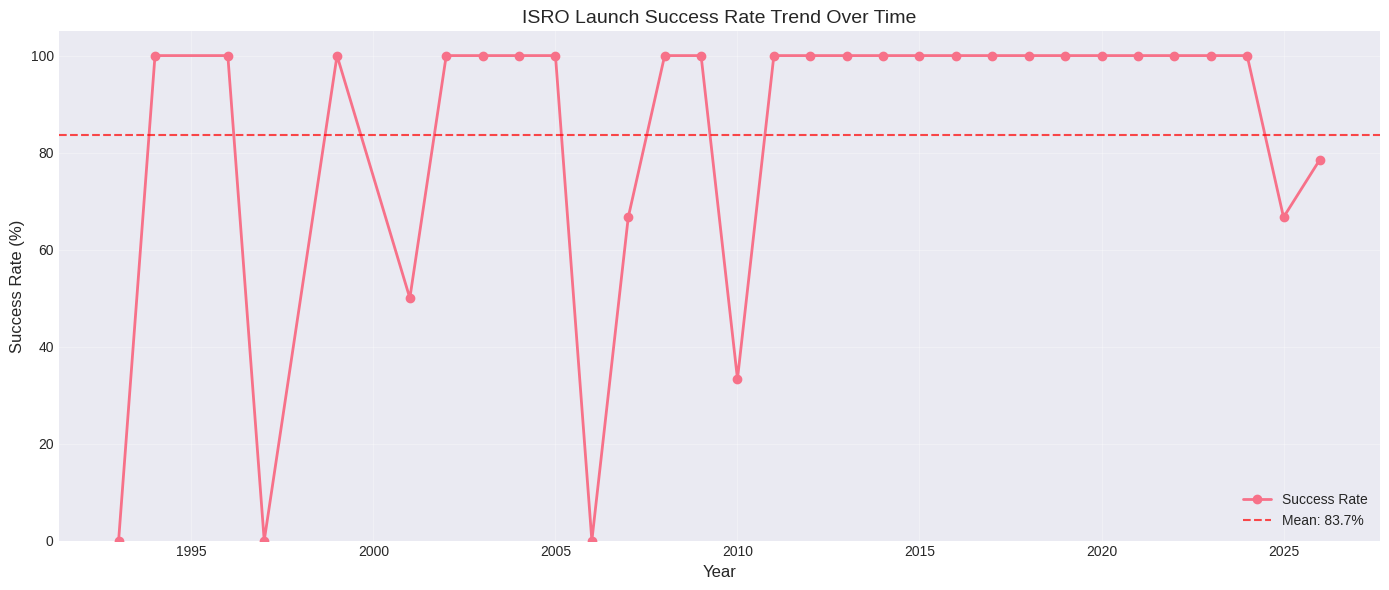

Figure saved: success_rate_over_time.png

 Overall success rate: 83.7%
Best year: 1994 (100.0%)
Worst year: 1993 (0.0%)


In [ ]:
# @title Block 29: Launch Success Rate Over Time

print("BLOCK 29: LAUNCH SUCCESS RATE OVER TIME")

fig, ax = plt.subplots(figsize=(14, 6))

yearly_stats = df.groupby('launch_year').agg({
    'launch_success': ['sum', 'count', 'mean']
}).reset_index()

yearly_stats.columns = ['year', 'successes', 'total', 'success_rate']
yearly_stats['success_rate_pct'] = yearly_stats['success_rate'] * 100

ax.plot(yearly_stats['year'], yearly_stats['success_rate_pct'],
        marker='o', linewidth=2, markersize=6, label='Success Rate')
ax.axhline(y=yearly_stats['success_rate_pct'].mean(),
           color='red', linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Mean: {yearly_stats["success_rate_pct"].mean():.1f}%')

ax.set_xlabel('Year')
ax.set_ylabel('Success Rate (%)')
ax.set_title('ISRO Launch Success Rate Trend Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'success_rate_over_time.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: success_rate_over_time.png")
print(f"\n Overall success rate: {yearly_stats['success_rate_pct'].mean():.1f}%")
print(f"Best year: {yearly_stats.loc[yearly_stats['success_rate_pct'].idxmax(), 'year']:.0f} ({yearly_stats['success_rate_pct'].max():.1f}%)")
print(f"Worst year: {yearly_stats.loc[yearly_stats['success_rate_pct'].idxmin(), 'year']:.0f} ({yearly_stats['success_rate_pct'].min():.1f}%)")


BLOCK 30: VEHICLE-WISE PERFORMANCE COMPARISON


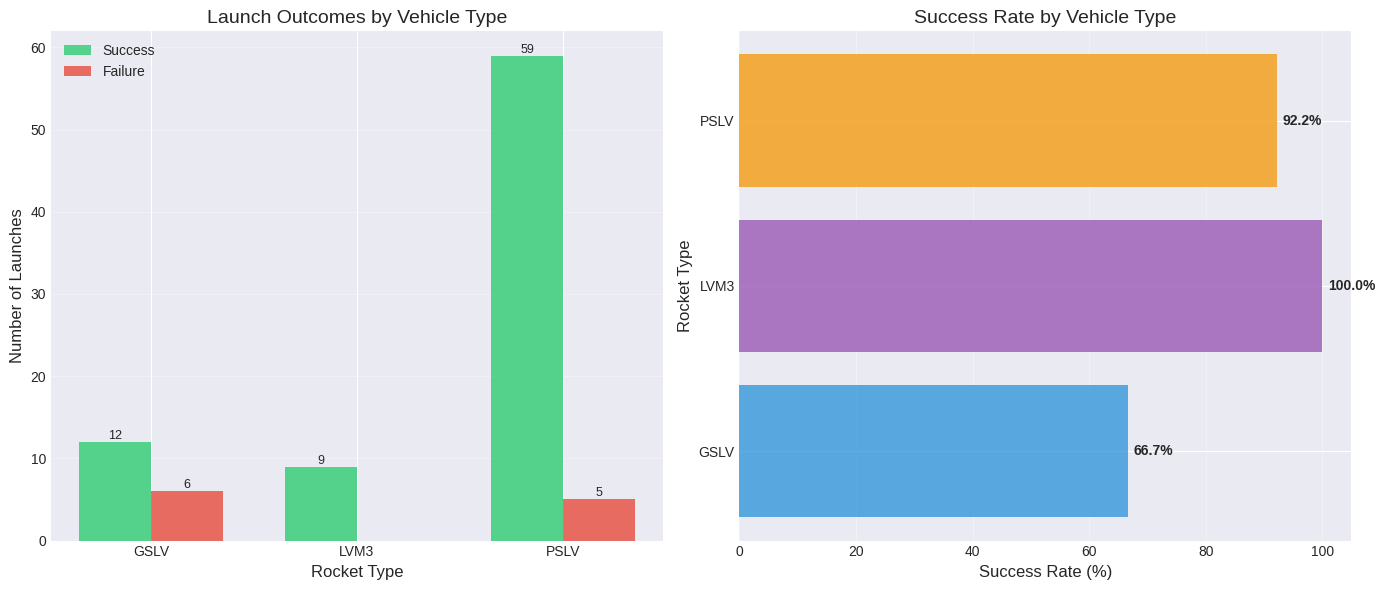

Figure saved: vehicle_performance_comparison.png

 Vehicle Performance Summary:
GSLV: 66.7% (12/18 launches)
LVM3: 100.0% (9/9 launches)
PSLV: 92.2% (59/64 launches)


In [ ]:
# @title Block 30: Vehicle-Wise Performance Comparison

print("BLOCK 30: VEHICLE-WISE PERFORMANCE COMPARISON")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

vehicle_stats = df.groupby('rocket_type').agg({
    'launch_success': ['sum', 'count', 'mean']
}).reset_index()
vehicle_stats.columns = ['rocket_type', 'successes', 'total', 'success_rate']
vehicle_stats['failures'] = vehicle_stats['total'] - vehicle_stats['successes']
vehicle_stats['success_rate_pct'] = vehicle_stats['success_rate'] * 100

colors = ['#2ecc71', '#e74c3c']
ax1 = axes[0]
x_pos = np.arange(len(vehicle_stats))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, vehicle_stats['successes'], width,
                label='Success', color=colors[0], alpha=0.8)
bars2 = ax1.bar(x_pos + width/2, vehicle_stats['failures'], width,
                label='Failure', color=colors[1], alpha=0.8)

ax1.set_xlabel('Rocket Type')
ax1.set_ylabel('Number of Launches')
ax1.set_title('Launch Outcomes by Vehicle Type')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(vehicle_stats['rocket_type'])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}', ha='center', va='bottom', fontsize=9)

ax2 = axes[1]
bars = ax2.barh(vehicle_stats['rocket_type'], vehicle_stats['success_rate_pct'],
                color=['#3498db', '#9b59b6', '#f39c12'], alpha=0.8)

ax2.set_xlabel('Success Rate (%)')
ax2.set_ylabel('Rocket Type')
ax2.set_title('Success Rate by Vehicle Type')
ax2.set_xlim(0, 105)
ax2.grid(axis='x', alpha=0.3)

for idx, (bar, rate) in enumerate(zip(bars, vehicle_stats['success_rate_pct'])):
    ax2.text(rate + 1, bar.get_y() + bar.get_height()/2,
             f'{rate:.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vehicle_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: vehicle_performance_comparison.png")
print(f"\n Vehicle Performance Summary:")
for _, row in vehicle_stats.iterrows():
    print(f"{row['rocket_type']}: {row['success_rate_pct']:.1f}% ({int(row['successes'])}/{int(row['total'])} launches)")


BLOCK 31: PAYLOAD MASS DISTRIBUTION ANALYSIS


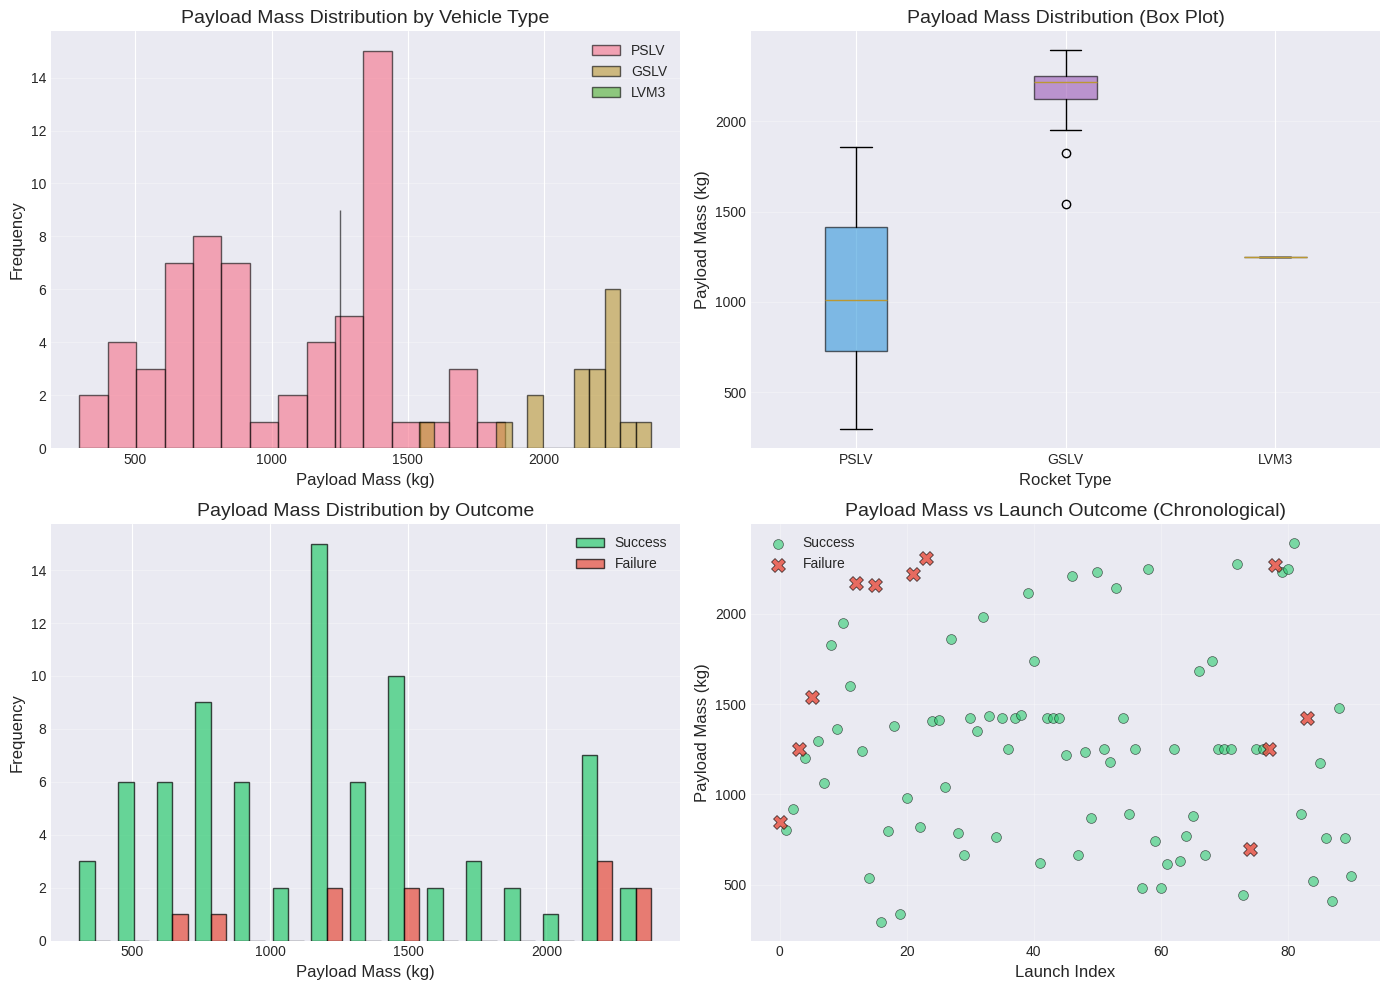

Figure saved: payload_mass_analysis.png

 Payload Mass Statistics:
Mean (Success): 1224.26 kg
Mean (Failure): 1648.55 kg
Median (Success): 1250.00 kg
Median (Failure): 1540.00 kg


In [ ]:
# @title Block 31: Payload Mass Distribution Analysis

print("BLOCK 31: PAYLOAD MASS DISTRIBUTION ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
for rocket_type in df['rocket_type'].unique():
    data = df[df['rocket_type'] == rocket_type]['payload_mass_kg'].dropna()
    ax1.hist(data, bins=15, alpha=0.6, label=rocket_type, edgecolor='black')

ax1.set_xlabel('Payload Mass (kg)')
ax1.set_ylabel('Frequency')
ax1.set_title('Payload Mass Distribution by Vehicle Type')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
payload_data = [df[df['rocket_type'] == rt]['payload_mass_kg'].dropna()
                for rt in df['rocket_type'].unique()]
bp = ax2.boxplot(payload_data, labels=df['rocket_type'].unique(), patch_artist=True)
for patch, color in zip(bp['boxes'], ['#3498db', '#9b59b6', '#f39c12']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.set_xlabel('Rocket Type')
ax2.set_ylabel('Payload Mass (kg)')
ax2.set_title('Payload Mass Distribution (Box Plot)')
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
success_mass = df[df['launch_success'] == 1]['payload_mass_kg'].dropna()
failure_mass = df[df['launch_success'] == 0]['payload_mass_kg'].dropna()

ax3.hist([success_mass, failure_mass], bins=15,
         label=['Success', 'Failure'], color=['#2ecc71', '#e74c3c'],
         alpha=0.7, edgecolor='black')
ax3.set_xlabel('Payload Mass (kg)')
ax3.set_ylabel('Frequency')
ax3.set_title('Payload Mass Distribution by Outcome')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]
scatter_data = df[['payload_mass_kg', 'launch_success']].dropna()
success_scatter = scatter_data[scatter_data['launch_success'] == 1]
failure_scatter = scatter_data[scatter_data['launch_success'] == 0]

ax4.scatter(success_scatter.index, success_scatter['payload_mass_kg'],
            c='#2ecc71', alpha=0.6, s=50, label='Success', edgecolors='black', linewidth=0.5)
ax4.scatter(failure_scatter.index, failure_scatter['payload_mass_kg'],
            c='#e74c3c', alpha=0.8, s=100, marker='X', label='Failure', edgecolors='black', linewidth=0.5)

ax4.set_xlabel('Launch Index')
ax4.set_ylabel('Payload Mass (kg)')
ax4.set_title('Payload Mass vs Launch Outcome (Chronological)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'payload_mass_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: payload_mass_analysis.png")
print(f"\n Payload Mass Statistics:")
print(f"Mean (Success): {success_mass.mean():.2f} kg")
print(f"Mean (Failure): {failure_mass.mean():.2f} kg")
print(f"Median (Success): {success_mass.median():.2f} kg")
print(f"Median (Failure): {failure_mass.median():.2f} kg")


BLOCK 32: TEMPORAL PATTERNS ANALYSIS


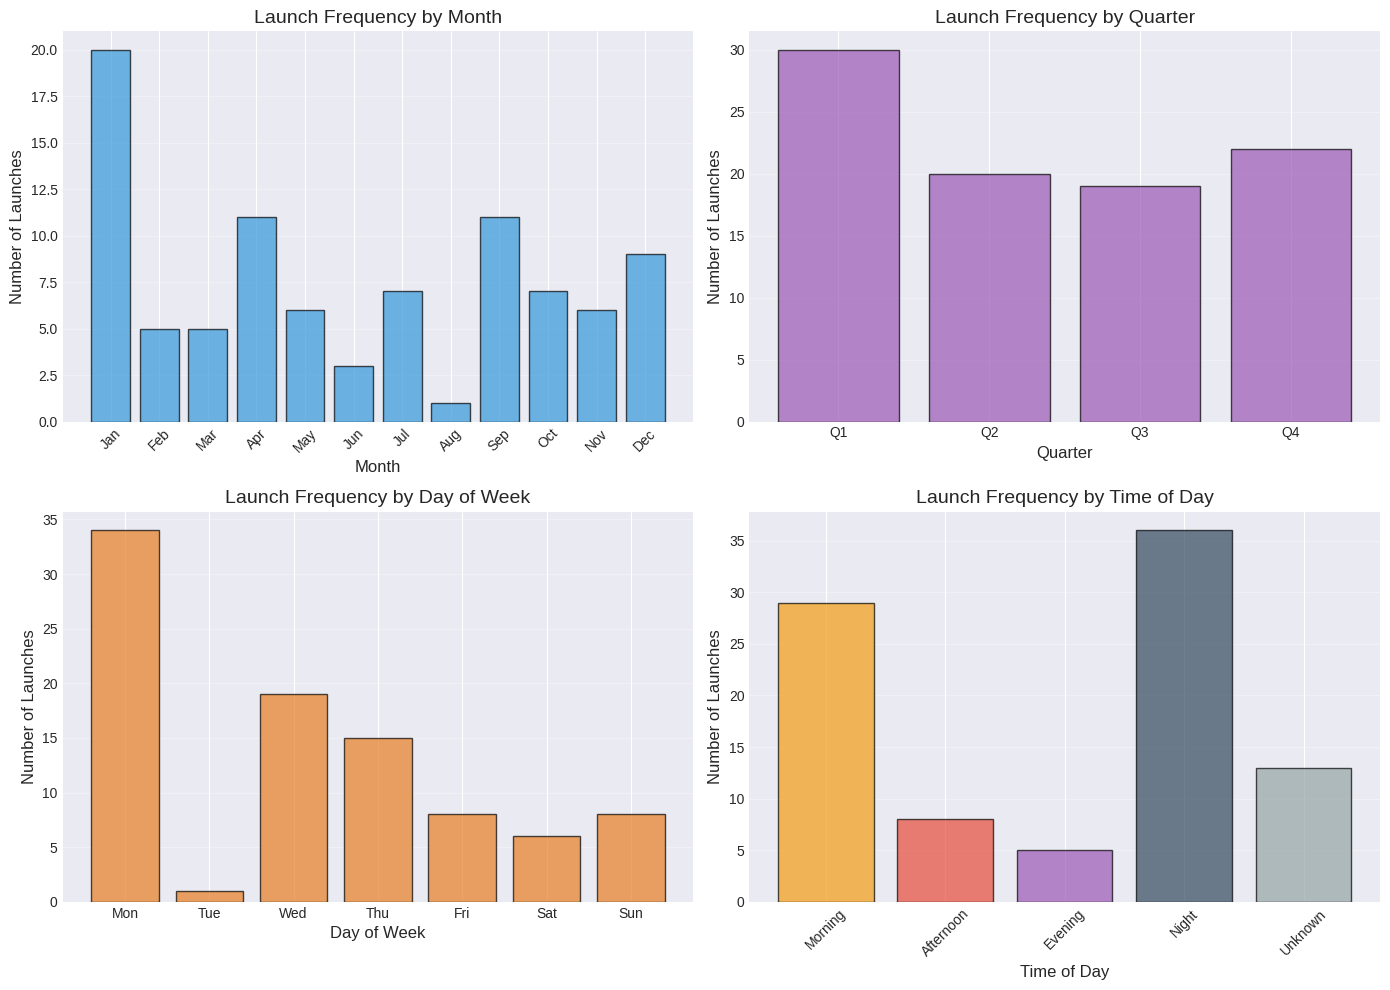

Figure saved: temporal_patterns.png

 Temporal Insights:
Most active month: Jan (20 launches)
Most active quarter: Q1 (30 launches)
Most active day: Mon (34 launches)
Monsoon season launches: 22 (24.2%)


In [ ]:
# @title Block 32: Temporal Patterns Analysis

print("BLOCK 32: TEMPORAL PATTERNS ANALYSIS")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
monthly_launches = df.groupby('launch_month').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bars = ax1.bar(range(1, 13), monthly_launches.reindex(range(1, 13), fill_value=0),
               color='#3498db', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Launches')
ax1.set_title('Launch Frequency by Month')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_names, rotation=45)
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[0, 1]
quarterly_launches = df.groupby('launch_quarter').size()
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
bars = ax2.bar(range(1, 5), quarterly_launches.reindex(range(1, 5), fill_value=0),
               color='#9b59b6', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Quarter')
ax2.set_ylabel('Number of Launches')
ax2.set_title('Launch Frequency by Quarter')
ax2.set_xticks(range(1, 5))
ax2.set_xticklabels(quarters)
ax2.grid(axis='y', alpha=0.3)

ax3 = axes[1, 0]
day_launches = df.groupby('launch_day_of_week').size()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
bars = ax3.bar(range(7), day_launches.reindex(range(7), fill_value=0),
               color='#e67e22', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Number of Launches')
ax3.set_title('Launch Frequency by Day of Week')
ax3.set_xticks(range(7))
ax3.set_xticklabels(day_names)
ax3.grid(axis='y', alpha=0.3)

ax4 = axes[1, 1]

# Recreate launch_time_category from encoded values
time_map_reverse = {0: 'Morning', 1: 'Afternoon', 2: 'Evening', 3: 'Night', -1: 'Unknown'}
df['launch_time_category'] = df['launch_time_encoded'].map(time_map_reverse)
time_launches = df.groupby('launch_time_category').size()

time_order = ['Morning', 'Afternoon', 'Evening', 'Night', 'Unknown']
time_present = [t for t in time_order if t in time_launches.index]
time_counts = [time_launches.get(t, 0) for t in time_present]
colors_map = {'Morning': '#f39c12', 'Afternoon': '#e74c3c',
              'Evening': '#9b59b6', 'Night': '#34495e', 'Unknown': '#95a5a6'}
bar_colors = [colors_map[t] for t in time_present]

bars = ax4.bar(range(len(time_present)), time_counts,
               color=bar_colors, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Time of Day')
ax4.set_ylabel('Number of Launches')
ax4.set_title('Launch Frequency by Time of Day')
ax4.set_xticks(range(len(time_present)))
ax4.set_xticklabels(time_present, rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'temporal_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: temporal_patterns.png")
print(f"\n Temporal Insights:")
if monthly_launches.max() > 0:
    most_active_month_idx = int(monthly_launches.idxmax())
    print(f"Most active month: {month_names[most_active_month_idx-1]} ({monthly_launches.max()} launches)")
    most_active_quarter = int(quarterly_launches.idxmax())
    print(f"Most active quarter: Q{most_active_quarter} ({quarterly_launches.max()} launches)")
    most_active_day = int(day_launches.idxmax())
    print(f"Most active day: {day_names[most_active_day]} ({day_launches.max()} launches)")
    print(f"Monsoon season launches: {df['is_monsoon_season'].sum()} ({df['is_monsoon_season'].sum()/len(df)*100:.1f}%)")
else:
    print("Insufficient temporal data for insights")



BLOCK 33: FEATURE CORRELATION HEATMAP


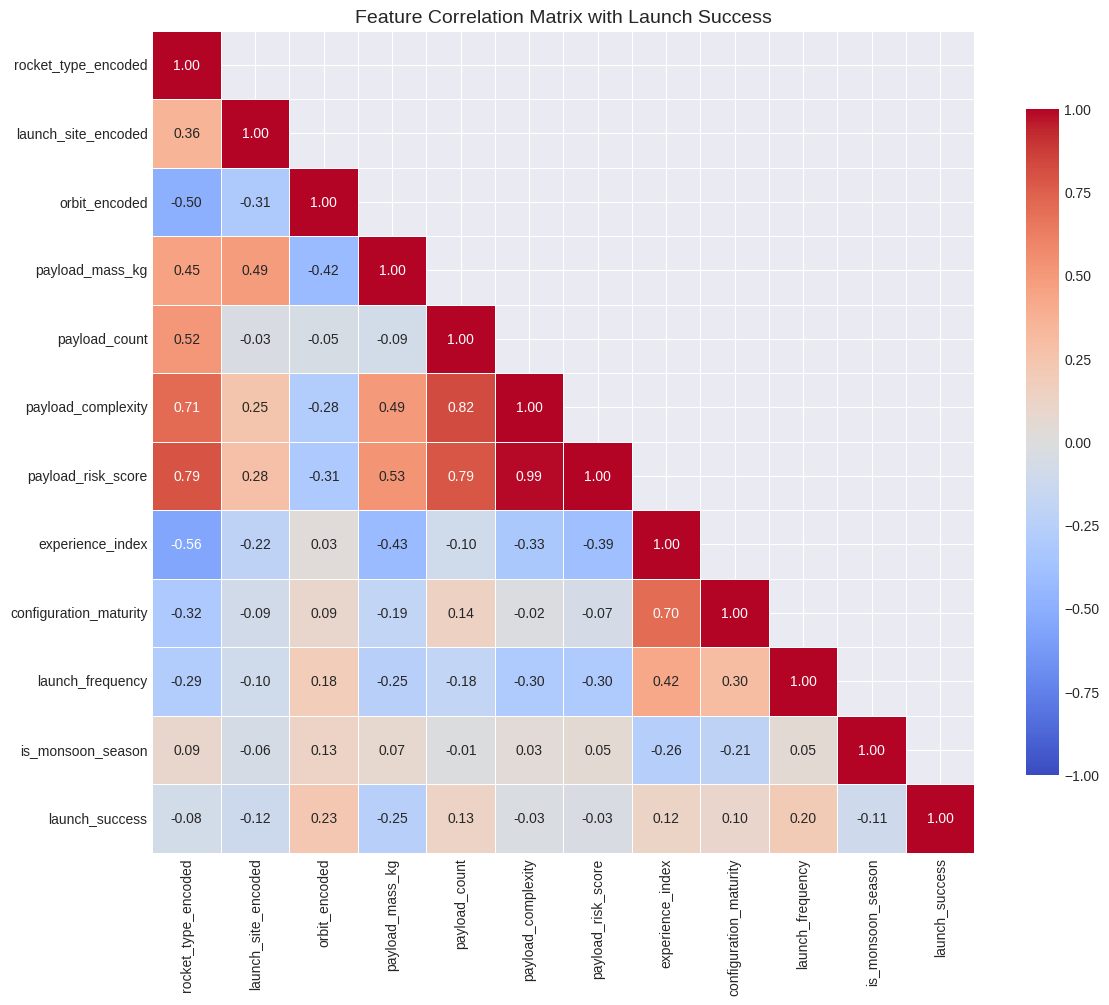

Figure saved: correlation_heatmap.png

Top 10 Features Correlated with Launch Success:
1. payload_mass_kg               : 0.250
2. orbit_encoded                 : 0.230
3. launch_frequency              : 0.198
4. payload_count                 : 0.128
5. launch_site_encoded           : 0.125
6. experience_index              : 0.120
7. is_monsoon_season             : 0.106
8. configuration_maturity        : 0.096
9. rocket_type_encoded           : 0.084
10. payload_risk_score            : 0.032


In [ ]:
# @title Block 33: Feature Correlation Heatmap

print("BLOCK 33: FEATURE CORRELATION HEATMAP")

numeric_features = [
    'rocket_type_encoded', 'launch_site_encoded', 'orbit_encoded',
    'payload_mass_kg', 'payload_count', 'payload_complexity',
    'payload_risk_score', 'experience_index', 'configuration_maturity',
    'launch_frequency', 'is_monsoon_season', 'launch_success'
]

available_features = [f for f in numeric_features if f in df.columns]
corr_matrix = df[available_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax, vmin=-1, vmax=1)

ax.set_title('Feature Correlation Matrix with Launch Success')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: correlation_heatmap.png")

correlations_with_target = corr_matrix['launch_success'].drop('launch_success').abs().sort_values(ascending=False)
print(f"\nTop 10 Features Correlated with Launch Success:")
for idx, (feature, corr) in enumerate(correlations_with_target.head(10).items(), 1):
    print(f"{idx}. {feature:30s}: {corr:.3f}")


BLOCK 34: EXPERIENCE INDEX IMPACT


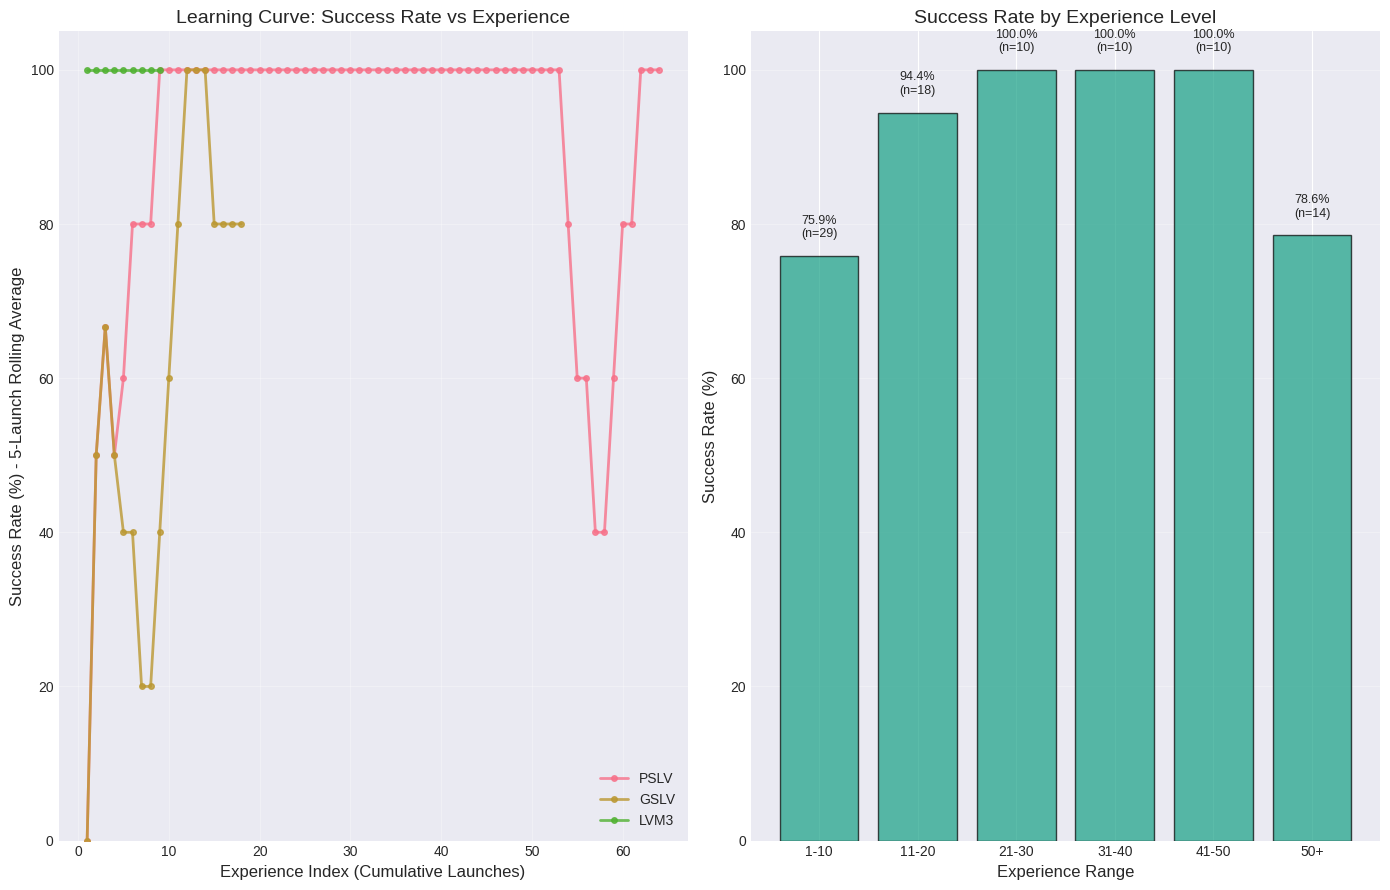

Figure saved: experience_impact.png

 Experience Impact Summary:
1-10      : 75.9% (29 launches)
11-20     : 94.4% (18 launches)
21-30     : 100.0% (10 launches)
31-40     : 100.0% (10 launches)
41-50     : 100.0% (10 launches)
50+       : 78.6% (14 launches)


In [ ]:
# @title Block 34: Experience Index Impact

print("BLOCK 34: EXPERIENCE INDEX IMPACT")

fig, axes = plt.subplots(1, 2, figsize=(14, 9))  # Changed figsize from 6 to 9, to fix data-lable overlap with title in subplot 'Success Rate by Experience Level'

ax1 = axes[0]
for rocket_type in df['rocket_type'].unique():
    rocket_df = df[df['rocket_type'] == rocket_type].sort_values('experience_index')

    window = 5
    if len(rocket_df) >= window:
        rolling_success = rocket_df.set_index('experience_index')['launch_success'].rolling(window=window, min_periods=1).mean() * 100
        ax1.plot(rolling_success.index, rolling_success.values,
                marker='o', label=rocket_type, linewidth=2, markersize=4, alpha=0.8)

ax1.set_xlabel('Experience Index (Cumulative Launches)')
ax1.set_ylabel('Success Rate (%) - 5-Launch Rolling Average')
ax1.set_title('Learning Curve: Success Rate vs Experience')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

ax2 = axes[1]
exp_bins = [0, 10, 20, 30, 40, 50, 100]
exp_labels = ['1-10', '11-20', '21-30', '31-40', '41-50', '50+']
df['exp_bin'] = pd.cut(df['experience_index'], bins=exp_bins, labels=exp_labels, include_lowest=True)

exp_success = df.groupby('exp_bin')['launch_success'].agg(['mean', 'count']).reset_index()
exp_success['success_rate_pct'] = exp_success['mean'] * 100

bars = ax2.bar(range(len(exp_success)), exp_success['success_rate_pct'],
               color='#16a085', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Experience Range')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Success Rate by Experience Level')
ax2.set_xticks(range(len(exp_success)))
ax2.set_xticklabels(exp_success['exp_bin'])
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 105)

for idx, (bar, rate, count) in enumerate(zip(bars, exp_success['success_rate_pct'], exp_success['count'])):
    ax2.text(bar.get_x() + bar.get_width()/2, rate + 2,
             f'{rate:.1f}%\n(n={int(count)})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'experience_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: experience_impact.png")
print(f"\n Experience Impact Summary:")
for _, row in exp_success.iterrows():
    print(f"{row['exp_bin']:10s}: {row['success_rate_pct']:.1f}% ({int(row['count'])} launches)")


BLOCK 35: MULTI-PAYLOAD ANALYSIS


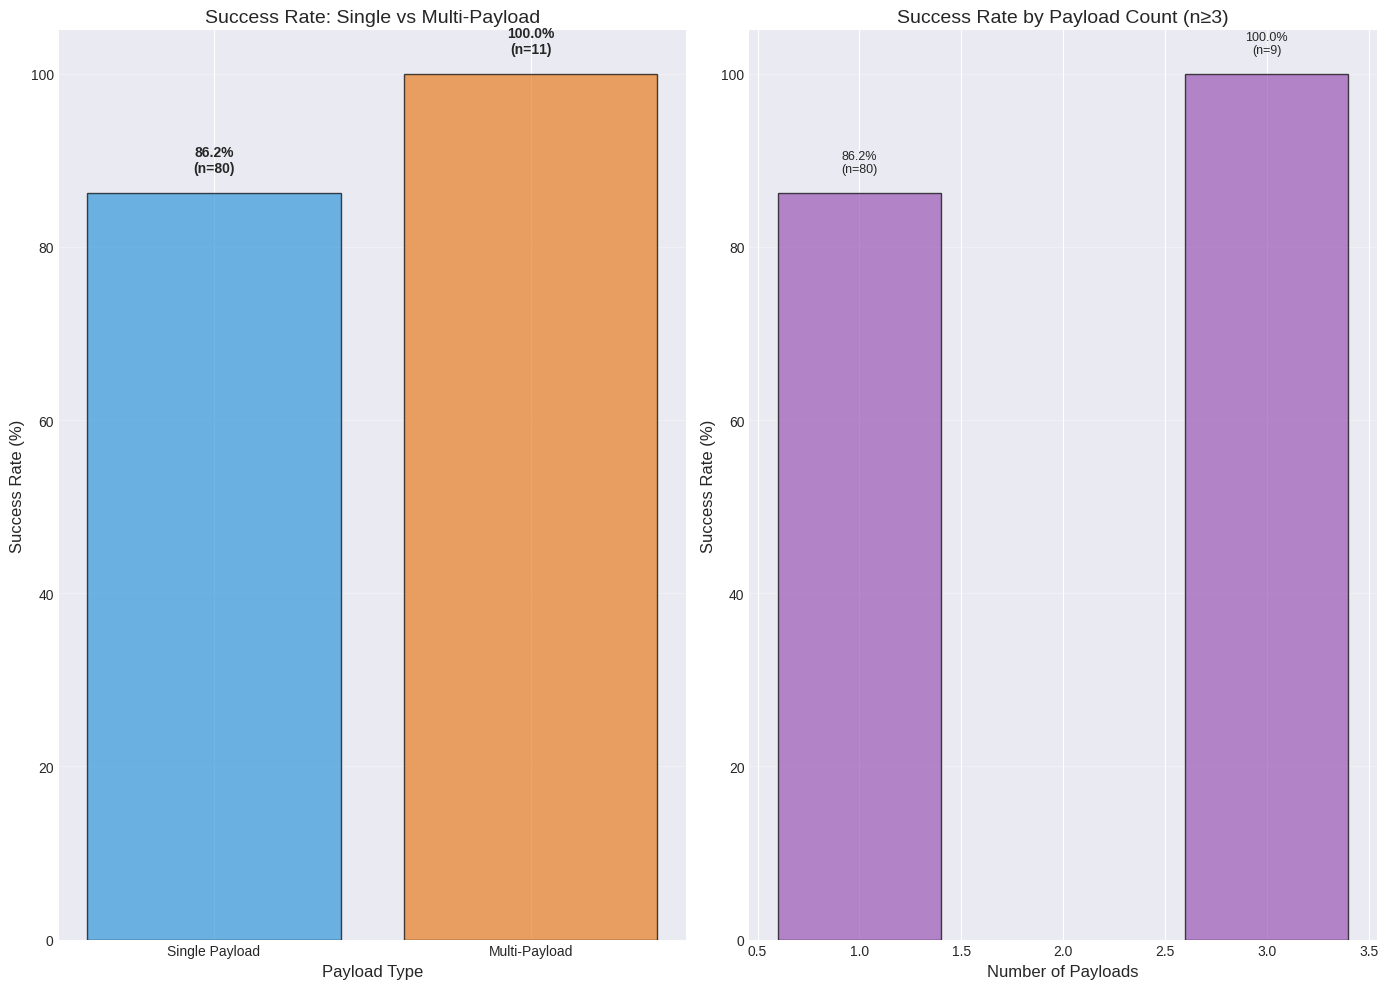

Figure saved: multi_payload_analysis.png

 Multi-Payload Impact:
Single payload success rate: 86.2%
Multi-payload success rate: 100.0%


In [ ]:
# @title Block 35: Multi-Payload Analysis

print("BLOCK 35: MULTI-PAYLOAD ANALYSIS")

fig, axes = plt.subplots(1, 2, figsize=(14, 10)) # Changed figsize from 6 to 10, to fix data-label & title, overlap in subplot 'Success Rate: Single vs Multi-Payload'

ax1 = axes[0]
payload_type_success = df.groupby('is_multi_payload')['launch_success'].agg(['mean', 'count']).reset_index()
payload_type_success['success_rate_pct'] = payload_type_success['mean'] * 100
payload_labels = ['Single Payload', 'Multi-Payload']

bars = ax1.bar(range(2), payload_type_success['success_rate_pct'],
               color=['#3498db', '#e67e22'], alpha=0.7, edgecolor='black')
ax1.set_xlabel('Payload Type')
ax1.set_ylabel('Success Rate (%)')
ax1.set_title('Success Rate: Single vs Multi-Payload')
ax1.set_xticks(range(2))
ax1.set_xticklabels(payload_labels)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 105)

for idx, (bar, rate, count) in enumerate(zip(bars, payload_type_success['success_rate_pct'], payload_type_success['count'])):
    ax1.text(bar.get_x() + bar.get_width()/2, rate + 2,
             f'{rate:.1f}%\n(n={int(count)})', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2 = axes[1]
payload_count_success = df.groupby('payload_count')['launch_success'].agg(['mean', 'count']).reset_index()
payload_count_success = payload_count_success[payload_count_success['count'] >= 3]
payload_count_success['success_rate_pct'] = payload_count_success['mean'] * 100

bars = ax2.bar(payload_count_success['payload_count'], payload_count_success['success_rate_pct'],
               color='#9b59b6', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Payloads')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Success Rate by Payload Count (n≥3)')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 105)

for bar, rate, count in zip(bars, payload_count_success['success_rate_pct'], payload_count_success['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, rate + 2,
             f'{rate:.1f}%\n(n={int(count)})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'multi_payload_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: multi_payload_analysis.png")
print(f"\n Multi-Payload Impact:")
print(f"Single payload success rate: {payload_type_success.iloc[0]['success_rate_pct']:.1f}%")
print(f"Multi-payload success rate: {payload_type_success.iloc[1]['success_rate_pct']:.1f}%")


BLOCK 36: CONFIGURATION MATURITY ANALYSIS


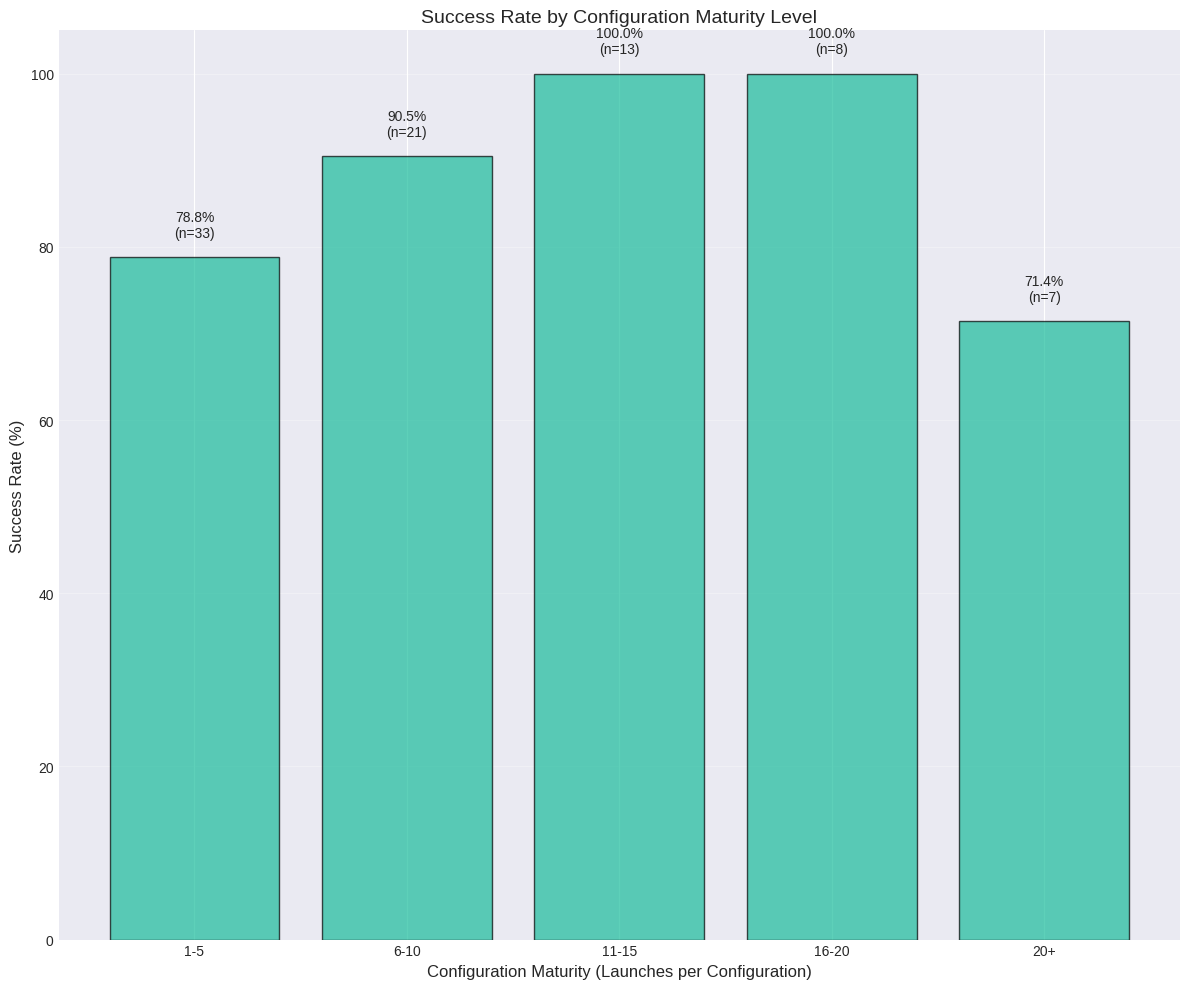

Figure saved: configuration_maturity.png

 Configuration Maturity Impact:
1-5       : 78.8% (33 launches)
6-10      : 90.5% (21 launches)
11-15     : 100.0% (13 launches)
16-20     : 100.0% (8 launches)
20+       : 71.4% (7 launches)


In [ ]:
# @title Block 36: Configuration Maturity Analysis

print("BLOCK 36: CONFIGURATION MATURITY ANALYSIS")

fig, ax = plt.subplots(figsize=(12, 10))

config_bins = [0, 5, 10, 15, 20, 30]
config_labels = ['1-5', '6-10', '11-15', '16-20', '20+']
df['config_bin'] = pd.cut(df['configuration_maturity'], bins=config_bins, labels=config_labels, include_lowest=True)

config_success = df.groupby('config_bin')['launch_success'].agg(['mean', 'count']).reset_index()
config_success['success_rate_pct'] = config_success['mean'] * 100

bars = ax.bar(range(len(config_success)), config_success['success_rate_pct'],
              color='#1abc9c', alpha=0.7, edgecolor='black')
ax.set_xlabel('Configuration Maturity (Launches per Configuration)')
ax.set_ylabel('Success Rate (%)')
ax.set_title('Success Rate by Configuration Maturity Level')
ax.set_xticks(range(len(config_success)))
ax.set_xticklabels(config_success['config_bin'])
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 105)

for idx, (bar, rate, count) in enumerate(zip(bars, config_success['success_rate_pct'], config_success['count'])):
    ax.text(bar.get_x() + bar.get_width()/2, rate + 2,
            f'{rate:.1f}%\n(n={int(count)})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'configuration_maturity.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: configuration_maturity.png")
print(f"\n Configuration Maturity Impact:")
for _, row in config_success.iterrows():
    print(f"{row['config_bin']:10s}: {row['success_rate_pct']:.1f}% ({int(row['count'])} launches)")


BLOCK 37: ORBIT TYPE SUCCESS ANALYSIS


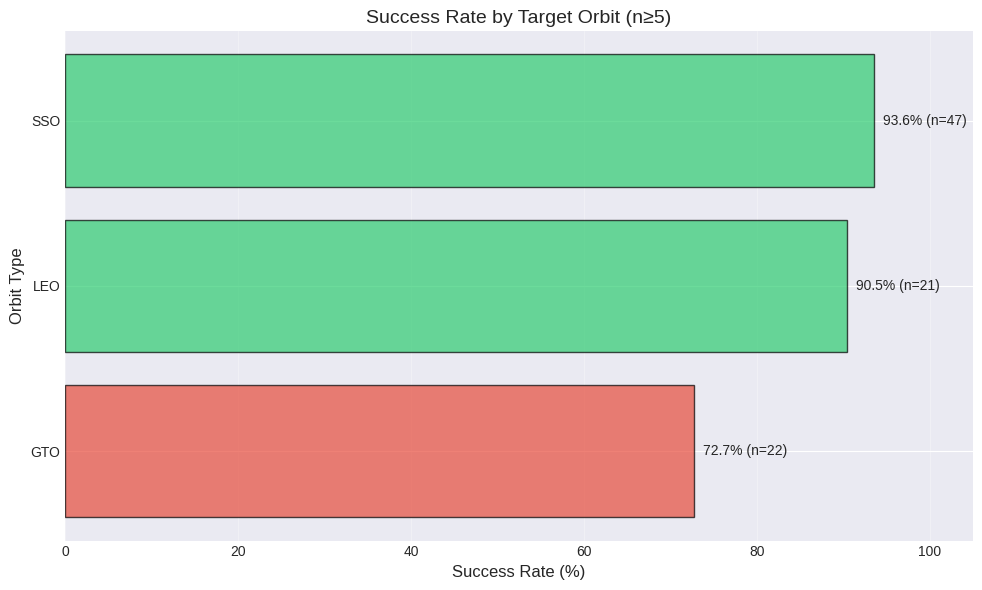

Figure saved: orbit_success_analysis.png

 Orbit Success Rates:
SSO            : 93.6% (47 launches)
LEO            : 90.5% (21 launches)
GTO            : 72.7% (22 launches)


In [ ]:
# @title Block 37: Orbit Type Success Analysis

print("BLOCK 37: ORBIT TYPE SUCCESS ANALYSIS")

# Recreate orbit_category from encoded values
orbit_map_reverse = {0: 'GTO', 1: 'LEO', 2: 'Other', 3: 'SSO', 4: 'Unknown'}
df['orbit_category'] = df['orbit_encoded'].map(orbit_map_reverse).fillna('Unknown')


orbit_success = df.groupby('orbit_category')['launch_success'].agg(['mean', 'count']).reset_index()
orbit_success = orbit_success[orbit_success['count'] >= 5]
orbit_success['success_rate_pct'] = orbit_success['mean'] * 100
orbit_success = orbit_success.sort_values('success_rate_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

colors_orbit = ['#e74c3c' if rate < 80 else '#f39c12' if rate < 90 else '#2ecc71'
                for rate in orbit_success['success_rate_pct']]

bars = ax.barh(orbit_success['orbit_category'], orbit_success['success_rate_pct'],
               color=colors_orbit, alpha=0.7, edgecolor='black')

ax.set_xlabel('Success Rate (%)')
ax.set_ylabel('Orbit Type')
ax.set_title('Success Rate by Target Orbit (n≥5)')
ax.set_xlim(0, 105)
ax.grid(axis='x', alpha=0.3)

for idx, (bar, rate, count) in enumerate(zip(bars, orbit_success['success_rate_pct'], orbit_success['count'])):
    ax.text(rate + 1, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}% (n={int(count)})', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'orbit_success_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: orbit_success_analysis.png")
print(f"\n Orbit Success Rates:")
for _, row in orbit_success.sort_values('success_rate_pct', ascending=False).iterrows():
    print(f"{row['orbit_category']:15s}: {row['success_rate_pct']:.1f}% ({int(row['count'])} launches)")


BLOCK 38: PAYLOAD RISK SCORE DISTRIBUTION


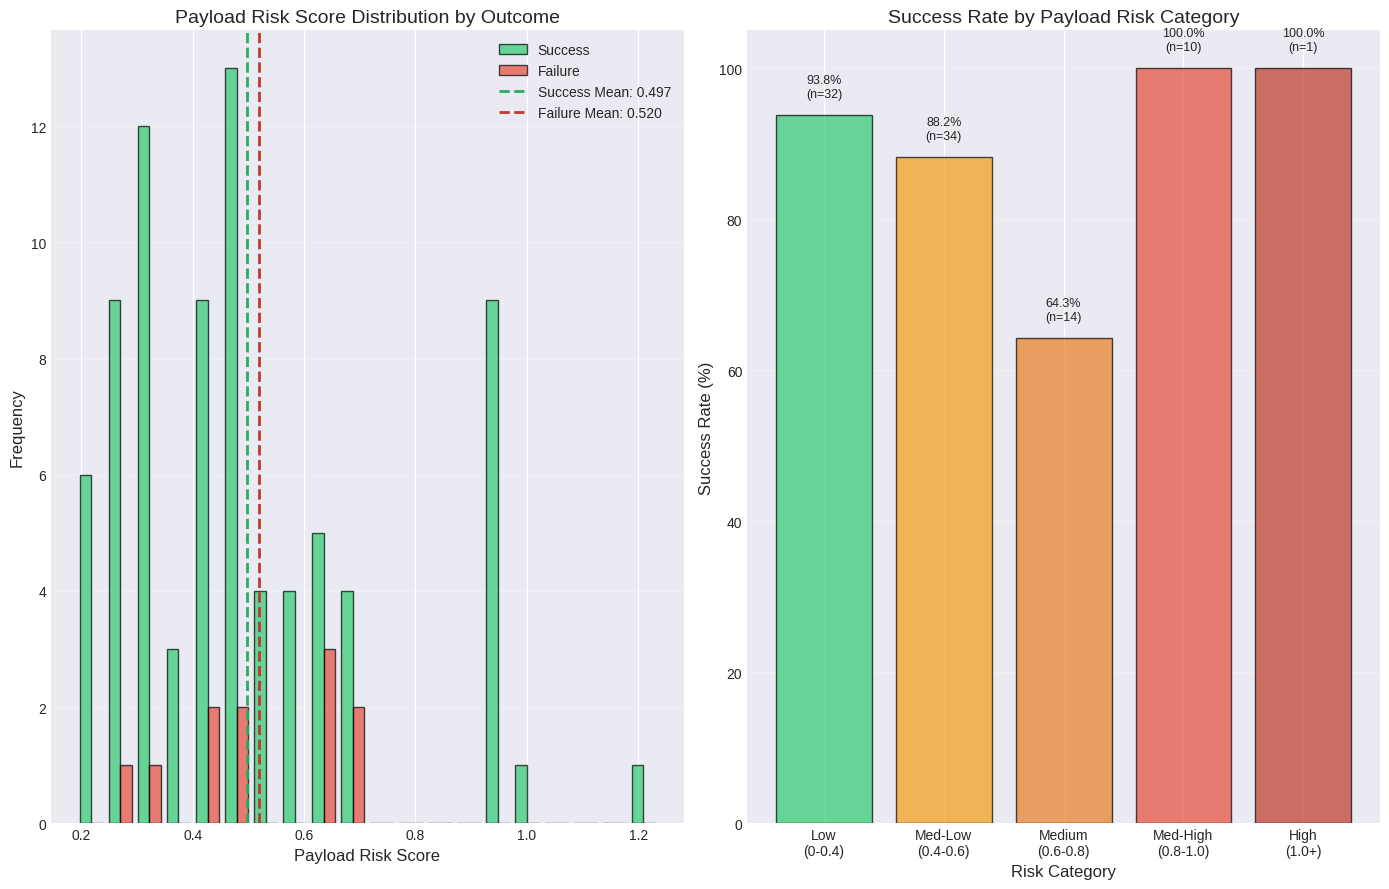

Figure saved: payload_risk_distribution.png

 Payload Risk Analysis:
Mean risk score (Success): 0.497
Mean risk score (Failure): 0.520

 Success Rate by Risk Category:
Low
(0-0.4)         : 93.8% (32 launches)
Med-Low
(0.4-0.6)   : 88.2% (34 launches)
Medium
(0.6-0.8)    : 64.3% (14 launches)
Med-High
(0.8-1.0)  : 100.0% (10 launches)
High
(1.0+)         : 100.0% (1 launches)


In [ ]:
# @title Block 38: Payload Risk Score Distribution

print("BLOCK 38: PAYLOAD RISK SCORE DISTRIBUTION")

fig, axes = plt.subplots(1, 2, figsize=(14, 9))

ax1 = axes[0]
success_risk = df[df['launch_success'] == 1]['payload_risk_score'].dropna()
failure_risk = df[df['launch_success'] == 0]['payload_risk_score'].dropna()

ax1.hist([success_risk, failure_risk], bins=20,
         label=['Success', 'Failure'], color=['#2ecc71', '#e74c3c'],
         alpha=0.7, edgecolor='black')
ax1.axvline(success_risk.mean(), color='#27ae60', linestyle='--', linewidth=2,
            label=f'Success Mean: {success_risk.mean():.3f}')
ax1.axvline(failure_risk.mean(), color='#c0392b', linestyle='--', linewidth=2,
            label=f'Failure Mean: {failure_risk.mean():.3f}')
ax1.set_xlabel('Payload Risk Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Payload Risk Score Distribution by Outcome')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
risk_bins = [0, 0.4, 0.6, 0.8, 1.0, 1.5]
risk_labels = ['Low\n(0-0.4)', 'Med-Low\n(0.4-0.6)', 'Medium\n(0.6-0.8)',
               'Med-High\n(0.8-1.0)', 'High\n(1.0+)']
df['risk_bin'] = pd.cut(df['payload_risk_score'], bins=risk_bins, labels=risk_labels, include_lowest=True)

risk_success = df.groupby('risk_bin')['launch_success'].agg(['mean', 'count']).reset_index()
risk_success['success_rate_pct'] = risk_success['mean'] * 100

colors_risk = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
bars = ax2.bar(range(len(risk_success)), risk_success['success_rate_pct'],
               color=colors_risk[:len(risk_success)], alpha=0.7, edgecolor='black')
ax2.set_xlabel('Risk Category')
ax2.set_ylabel('Success Rate (%)')
ax2.set_title('Success Rate by Payload Risk Category')
ax2.set_xticks(range(len(risk_success)))
ax2.set_xticklabels(risk_success['risk_bin'])
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 105)

for idx, (bar, rate, count) in enumerate(zip(bars, risk_success['success_rate_pct'], risk_success['count'])):
    ax2.text(bar.get_x() + bar.get_width()/2, rate + 2,
             f'{rate:.1f}%\n(n={int(count)})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'payload_risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: payload_risk_distribution.png")
print(f"\n Payload Risk Analysis:")
print(f"Mean risk score (Success): {success_risk.mean():.3f}")
print(f"Mean risk score (Failure): {failure_risk.mean():.3f}")
print(f"\n Success Rate by Risk Category:")
for _, row in risk_success.iterrows():
    print(f"{str(row['risk_bin']):20s}: {row['success_rate_pct']:.1f}% ({int(row['count'])} launches)")


BLOCK 39: LAUNCH FREQUENCY TRENDS


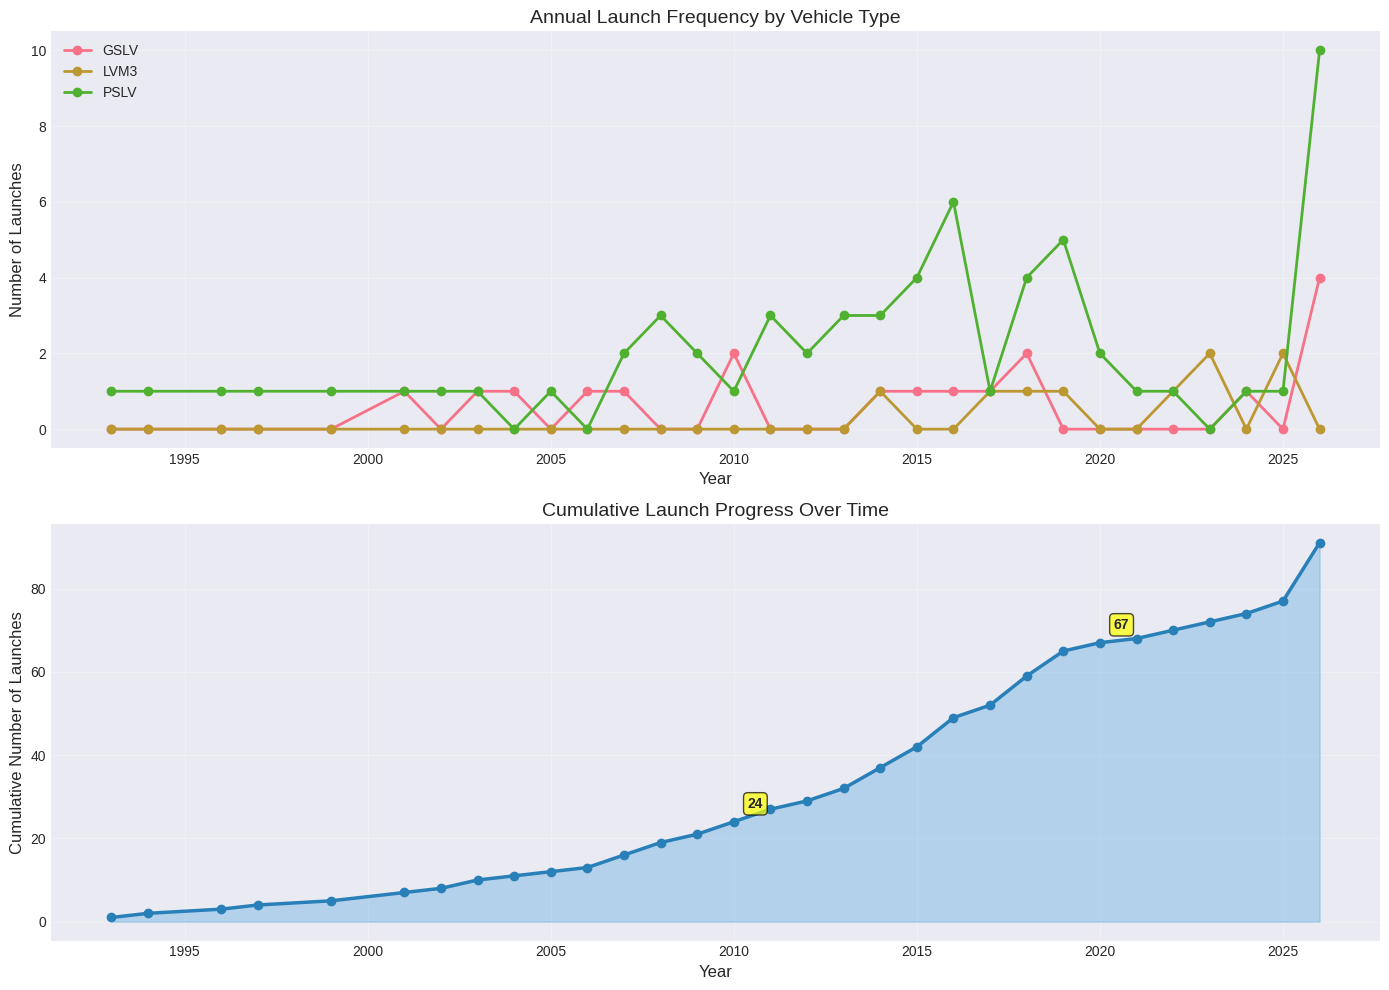

Figure saved: launch_frequency_trends.png

 Launch Frequency Summary:
Total launches: 91
Average launches per year: 2.9
Peak year: 2026.0 (14 launches)
Recent 5-year average: 4.6 launches/year


In [ ]:
# @title Block 39: Launch Frequency Trends

print("BLOCK 39: LAUNCH FREQUENCY TRENDS")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax1 = axes[0]
yearly_launches = df.groupby(['launch_year', 'rocket_type']).size().unstack(fill_value=0)

for rocket_type in yearly_launches.columns:
    ax1.plot(yearly_launches.index, yearly_launches[rocket_type],
            marker='o', label=rocket_type, linewidth=2, markersize=6)

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Launches')
ax1.set_title('Annual Launch Frequency by Vehicle Type')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
yearly_total = df.groupby('launch_year').size()
cumulative_launches = yearly_total.cumsum()

ax2.fill_between(cumulative_launches.index, cumulative_launches.values,
                 alpha=0.3, color='#3498db')
ax2.plot(cumulative_launches.index, cumulative_launches.values,
         marker='o', color='#2980b9', linewidth=2.5, markersize=6)

ax2.set_xlabel('Year')
ax2.set_ylabel('Cumulative Number of Launches')
ax2.set_title('Cumulative Launch Progress Over Time')
ax2.grid(True, alpha=0.3)

for year in [2000, 2010, 2020]:
    if year in cumulative_launches.index:
        count = cumulative_launches[year]
        ax2.annotate(f'{int(count)}', xy=(year, count),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'launch_frequency_trends.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Figure saved: launch_frequency_trends.png")
print(f"\n Launch Frequency Summary:")
print(f"Total launches: {len(df)}")
print(f"Average launches per year: {len(df) / df['launch_year'].nunique():.1f}")
print(f"Peak year: {yearly_total.idxmax()} ({yearly_total.max()} launches)")
print(f"Recent 5-year average: {yearly_total.tail(5).mean():.1f} launches/year")


In [ ]:
# @title Block 40: EDA Summary Report

print("BLOCK 40: EDA SUMMARY REPORT")

print("\n EXPLORATORY DATA ANALYSIS - KEY FINDINGS")
print("\n 1. OVERALL PERFORMANCE")
overall_success_rate = (df['launch_success'].sum() / len(df)) * 100
print(f"   Total launches analyzed: {len(df)}")
print(f"   Overall success rate: {overall_success_rate:.1f}%")
print(f"   Date range: {df['launch_year'].min():.0f} - {df['launch_year'].max():.0f}")

print("\n 2. VEHICLE-WISE PERFORMANCE")
for rocket_type in df['rocket_type'].unique():
    rocket_df = df[df['rocket_type'] == rocket_type]
    success_rate = (rocket_df['launch_success'].sum() / len(rocket_df)) * 100
    print(f"   {rocket_type}: {success_rate:.1f}% ({rocket_df['launch_success'].sum()}/{len(rocket_df)} launches)")

print("\n 3. TEMPORAL PATTERNS")
monthly_launches = df.groupby('launch_month').size()
print(f"   Most active month: {monthly_launches.idxmax()} ({monthly_launches.max()} launches)")
print(f"   Monsoon season launches: {df['is_monsoon_season'].sum()} ({df['is_monsoon_season'].sum()/len(df)*100:.1f}%)")

yearly_total = df.groupby('launch_year').size()
print(f"   Peak year: {yearly_total.idxmax():.0f} ({yearly_total.max()} launches)")
print(f"   Recent 5-year average: {yearly_total.tail(5).mean():.1f} launches/year")

print("\n 4. PAYLOAD INSIGHTS")
success_mass = df[df['launch_success'] == 1]['payload_mass_kg'].dropna()
failure_mass = df[df['launch_success'] == 0]['payload_mass_kg'].dropna()
print(f"   Average payload mass (Success): {success_mass.mean():.2f} kg")
print(f"   Average payload mass (Failure): {failure_mass.mean():.2f} kg")

multi_payload_rate = df[df['is_multi_payload'] == 1]['launch_success'].mean() * 100
single_payload_rate = df[df['is_multi_payload'] == 0]['launch_success'].mean() * 100
print(f"   Multi-payload success rate: {multi_payload_rate:.1f}%")
print(f"   Single-payload success rate: {single_payload_rate:.1f}%")

print("\n 5. EXPERIENCE & MATURITY EFFECTS")
correlations_with_target = df[['experience_index', 'configuration_maturity',
                                'payload_risk_score', 'launch_success']].corr()['launch_success'].drop('launch_success')
print(f"   Experience index correlation: {correlations_with_target['experience_index']:.3f}")
print(f"   Configuration maturity correlation: {correlations_with_target['configuration_maturity']:.3f}")
print(f"   Payload risk score correlation: {correlations_with_target['payload_risk_score']:.3f}")

print("\n 6. KEY RISK FACTORS IDENTIFIED")
top_correlations = df.select_dtypes(include=[np.number]).corrwith(df['launch_success']).abs().sort_values(ascending=False)
top_correlations = top_correlations[top_correlations.index != 'launch_success'].head(5)
print("   Top 5 predictive features:")
for idx, (feature, corr) in enumerate(top_correlations.items(), 1):
    print(f"   {idx}. {feature}: {corr:.3f}")

print("\n 7. FIGURES GENERATED")
figure_files = list(FIGURES_DIR.glob('*.png'))
print(f"   Total figures saved: {len(figure_files)}")
for fig_file in sorted(figure_files):
    print(f"   - {fig_file.name}")

print(f"\n 8. DATA READINESS FOR ML")
print(f"   Features available: {len(df.columns)}")
print(f"   Missing values: {df.isnull().sum().sum()}")
print(f"   Class balance: {overall_success_rate:.1f}% success / {100-overall_success_rate:.1f}% failure")
print(f"   Recommendation: Use stratified sampling and consider SMOTE for class balance")

print("\n EDA COMPLETE")
print(f"All visualizations saved to: {FIGURES_DIR}")
print("\n READY FOR NEXT PHASE: 04_ML_Model.ipynb")


BLOCK 40: EDA SUMMARY REPORT

 EXPLORATORY DATA ANALYSIS - KEY FINDINGS

 1. OVERALL PERFORMANCE
   Total launches analyzed: 91
   Overall success rate: 87.9%
   Date range: 1993 - 2026

 2. VEHICLE-WISE PERFORMANCE
   PSLV: 92.2% (59/64 launches)
   GSLV: 66.7% (12/18 launches)
   LVM3: 100.0% (9/9 launches)

 3. TEMPORAL PATTERNS
   Most active month: 1.0 (20 launches)
   Monsoon season launches: 22 (24.2%)
   Peak year: 2026 (14 launches)
   Recent 5-year average: 4.6 launches/year

 4. PAYLOAD INSIGHTS
   Average payload mass (Success): 1224.26 kg
   Average payload mass (Failure): 1648.55 kg
   Multi-payload success rate: 100.0%
   Single-payload success rate: 86.2%

 5. EXPERIENCE & MATURITY EFFECTS
   Experience index correlation: 0.120
   Configuration maturity correlation: 0.096
   Payload risk score correlation: -0.032

 6. KEY RISK FACTORS IDENTIFIED
   Top 5 predictive features:
   1. outcome_encoded: 0.964
   2. payload_mass_normalized: 0.250
   3. payload_mass_kg: 0.250
 